# Notebook 1: Análisis Exploratorio y Preprocesamiento de Datos

## Proyecto: Análisis de Perfiles Operativos en Cliente Industrial

**Objetivo:** Realizar la exploración inicial del dataset de consumo eléctrico industrial, identificar patrones, realizar limpieza de datos y generar features derivadas para análisis posterior.

**Dataset:** Datos de medición eléctrica trifásica con intervalos de 15 minutos (Octubre 2025)

---

### Contenido del Notebook

1. **Configuración del Entorno**
2. **Carga y Exploración Inicial de Datos**
3. **Limpieza de Datos**
4. **Análisis Exploratorio Univariado**
5. **Análisis Exploratorio Bivariado**
6. **Análisis Temporal**
7. **Feature Engineering**
8. **Detección de Outliers**
9. **Normalización y Preparación Final**
10. **Resumen y Exportación**

## 1. Configuración del Entorno

Importamos las librerías necesarias y configuramos el entorno de trabajo.

In [ ]:
# Importar librerías estándar
import pandas as pd
import numpy as np
import sys
import os
from pathlib import Path

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configuración
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Agregar directorio src al path para importar utilidades
sys.path.append(str(Path.cwd().parent / 'src'))

# Importar funciones auxiliares
from utils import (
    load_electrical_data,
    remove_constant_columns,
    engineer_temporal_features,
    engineer_electrical_features,
    prepare_features_for_ml,
    detect_outliers_iqr,
    get_cluster_statistics
)

print("Librerías importadas exitosamente")
print(f"Versión de Python: {sys.version}")
print(f"Versión de Pandas: {pd.__version__}")
print(f"Versión de NumPy: {np.__version__}")

✓ Librerías importadas exitosamente
Versión de Python: 3.13.4 (tags/v3.13.4:8a526ec, Jun  3 2025, 17:46:04) [MSC v.1943 64 bit (AMD64)]
Versión de Pandas: 2.3.3
Versión de NumPy: 2.3.4


## 2. Carga y Exploración Inicial de Datos

Cargamos el dataset y realizamos una primera inspección de su estructura.

In [ ]:
# Cargar dataset
data_path = Path.cwd().parent / 'data' / 'set_Datos_electricos.csv'
df_raw = load_electrical_data(str(data_path))

print(f"Dataset cargado exitosamente")
print(f"\nDimensiones del dataset: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas")
print(f"Periodo de datos: {df_raw['FECHA'].min()} a {df_raw['FECHA'].max()}")
print(f"Duración: {(df_raw['FECHA'].max() - df_raw['FECHA'].min()).days + 1} días")

✓ Dataset cargado exitosamente

Dimensiones del dataset: 2,881 filas × 47 columnas
Periodo de datos: 2025-10-01 00:00:00+00:00 a 2025-10-31 00:00:00+00:00
Duración: 31 días


In [3]:
# Visualizar primeras filas
print("Primeras 5 filas del dataset:\n")
df_raw.head()

Primeras 5 filas del dataset:



,CATEGORIA,DENSIDADCARGA,TIPO_INSTALACION,FECHA,HORA,INTERVALO,KWHD,KWHR,KVARHR,KVAHD,KVARH_LAG,KVARHR_1,KVARH_LEAD,PHASOR_KVAH,IA,IB,IC,AVG_IA_HARMONICS,AVG_IB_HARMONICS,AVG_IC_HARMONICS,VA,VB,VC,THD_VOLT_FASE_A,THD_VOLT_FASE_B,THD_VOLT_FASE_C,THD_CORRIENTE_FASE_A,THD_CORRIENTE_FASE_B,THD_CORRIENTE_FASE_C,KWD,KWR,KVARD,KVAD,NOMINAL_VOLTAGE_NVO,PT,CT,VA_DESV,VB_DESV,VC_DESV,IA_DESV,IB_DESV,IC_DESV,VOLTAJE_PROM,VOLTAJE_DESV_MAX,VOLTAJE_DESV_PORCENTAJE,CORRIENTE_PROM,CORRIENTE_DESV_MAX
0,CLIENTE INDUSTRIAL,ALTA,PRIMARIA,2025-10-08 13:30:00+00:00,13,13:30,27.12,0.00,0.00,27.18,0.00,0.00,0.00,0.00,1.00,2.00,3.00,1.00,2.00,3.00,13320.10,13416.10,13452.10,0.02,0.02,0.02,0.18,0.12,0.12,108.48,0.00,0.00,108.72,13198.61,14400:120,50:5,121.49,217.49,253.49,1.00,0.00,1.00,13396.10,253.49,0.02,2.00,1.00
1,CLIENTE INDUSTRIAL,ALTA,PRIMARIA,2025-10-29 10:00:00+00:00,10,10:00,26.04,0.00,0.00,26.16,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,2.00,2.00,13296.10,13368.10,13404.10,0.02,0.02,0.02,0.21,0.18,0.18,104.16,0.00,0.00,104.64,13198.61,14400:120,50:5,97.49,169.49,205.49,0.67,0.33,0.33,13356.10,205.49,0.02,1.67,0.67
2,CLIENTE INDUSTRIAL,ALTA,PRIMARIA,2025-10-29 11:15:00+00:00,11,11:15,23.88,0.00,0.00,23.94,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,2.00,2.00,13368.10,13440.10,13476.10,0.02,0.02,0.02,0.21,0.17,0.16,95.52,0.00,0.00,95.76,13198.61,14400:120,50:5,169.49,241.49,277.49,0.67,0.33,0.33,13428.10,277.49,0.02,1.67,0.67
3,CLIENTE INDUSTRIAL,ALTA,PRIMARIA,2025-10-14 18:30:00+00:00,18,18:30,27.42,0.00,0.00,28.32,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,2.00,2.00,13236.10,13272.10,13380.10,0.03,0.03,0.03,0.29,0.23,0.26,109.68,0.00,0.00,113.28,13198.61,14400:120,50:5,37.49,73.49,181.49,0.67,0.33,0.33,13296.10,181.49,0.01,1.67,0.67
4,CLIENTE INDUSTRIAL,ALTA,PRIMARIA,2025-10-15 19:15:00+00:00,19,19:15,21.78,0.00,0.00,22.14,0.00,0.00,0.00,0.00,1.00,2.00,2.00,1.00,2.00,2.00,13224.10,13272.10,13380.10,0.03,0.03,0.03,0.18,0.18,0.19,87.12,0.00,0.00,88.56,13198.61,14400:120,50:5,25.49,73.49,181.49,0.67,0.33,0.33,13292.10,181.49,0.01,1.67,0.67


In [4]:
# Información general del dataset
print("Información del dataset:\n")
df_raw.info()

Información del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2881 entries, 0 to 2880
Data columns (total 47 columns):
 #   Column                   Non-Null Count  Dtype              
---  ------                   --------------  -----              
 0   CATEGORIA                2881 non-null   object             
 1   DENSIDADCARGA            2881 non-null   object             
 2   TIPO_INSTALACION         2881 non-null   object             
 3   FECHA                    2881 non-null   datetime64[ns, UTC]
 4   HORA                     2881 non-null   int64              
 5   INTERVALO                2881 non-null   object             
 6   KWHD                     2881 non-null   float64            
 7   KWHR                     2881 non-null   float64            
 8   KVARHR                   2881 non-null   float64            
 9   KVAHD                    2881 non-null   float64            
 10  KVARH_LAG                2881 non-null   float64            
 11  KVAR

In [5]:
# Estadísticas descriptivas
print("Estadísticas descriptivas de variables numéricas:\n")
df_raw.describe().T

Estadísticas descriptivas de variables numéricas:



,count,mean,std,min,25%,50%,75%,max
HORA,2881.00,11.50,6.93,0.00,5.00,11.00,17.00,23.00
KWHD,2881.00,14.32,7.89,0.48,6.24,14.34,20.76,36.66
KWHR,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
KVARHR,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
KVAHD,2881.00,14.53,8.09,2.10,6.24,14.34,21.00,37.92
KVARH_LAG,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
KVARHR_1,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
KVARH_LEAD,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
PHASOR_KVAH,2881.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
IA,2881.00,0.63,0.69,0.00,0.00,1.00,1.00,3.00


In [ ]:
# Verificar valores faltantes
missing_values = df_raw.isnull().sum()
missing_percent = 100 * missing_values / len(df_raw)

missing_df = pd.DataFrame({
    'Valores Faltantes': missing_values,
    'Porcentaje (%)': missing_percent
})

print("Análisis de valores faltantes:\n")
print(missing_df[missing_df['Valores Faltantes'] > 0].sort_values('Valores Faltantes', ascending=False))

if missing_df['Valores Faltantes'].sum() == 0:
    print("\nNo se encontraron valores faltantes en el dataset")

Análisis de valores faltantes:

Empty DataFrame
Columns: [Valores Faltantes, Porcentaje (%)]
Index: []

✓ No se encontraron valores faltantes en el dataset


## 3. Limpieza de Datos

Identificamos y eliminamos columnas con varianza cero o constantes que no aportan información para el análisis.

In [ ]:
# Eliminar columnas constantes o con varianza cero
df_clean, removed_cols = remove_constant_columns(df_raw, threshold=0.0)

print(f"Columnas eliminadas ({len(removed_cols)}):")
for col in removed_cols:
    unique_vals = df_raw[col].nunique()
    print(f"  - {col}: {unique_vals} valor(es) único(s)")

print(f"\nDimensiones después de limpieza: {df_clean.shape[0]:,} filas × {df_clean.shape[1]} columnas")
print(f"Columnas eliminadas: {len(removed_cols)}")
print(f"Columnas restantes: {df_clean.shape[1]}")

✓ Columnas eliminadas (8):
  - KWHR: 1 valor(es) único(s)
  - KVARHR: 1 valor(es) único(s)
  - KVARH_LAG: 1 valor(es) único(s)
  - KVARHR_1: 1 valor(es) único(s)
  - KVARH_LEAD: 1 valor(es) único(s)
  - PHASOR_KVAH: 1 valor(es) único(s)
  - KWR: 1 valor(es) único(s)
  - KVARD: 1 valor(es) único(s)

Dimensiones después de limpieza: 2,881 filas × 39 columnas
Columnas eliminadas: 8
Columnas restantes: 39


## 4. Análisis Exploratorio Univariado

Analizamos la distribución de las variables principales del dataset.

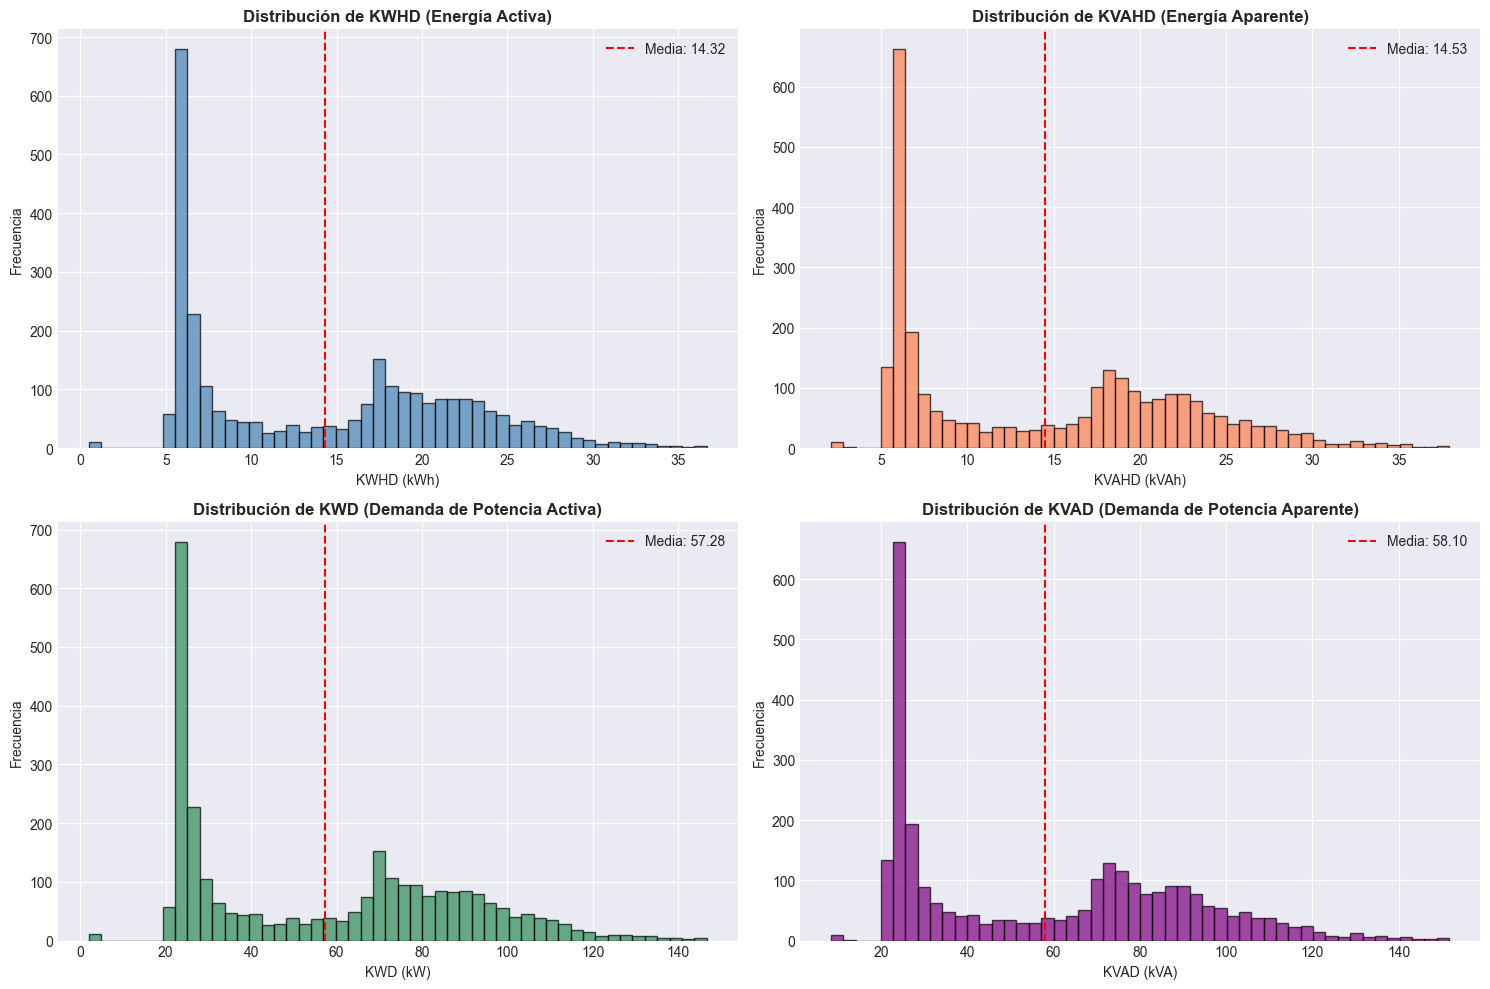

Estadísticas de variables de consumo:
         KWHD   KVAHD     KWD    KVAD
count 2881.00 2881.00 2881.00 2881.00
mean    14.32   14.53   57.28   58.10
std      7.89    8.09   31.56   32.37
min      0.48    2.10    1.92    8.40
25%      6.24    6.24   24.96   24.96
50%     14.34   14.34   57.36   57.36
75%     20.76   21.00   83.04   84.00
max     36.66   37.92  146.64  151.68


In [8]:
# Distribución de variables de consumo energético
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# KWHD - Energía activa
axes[0, 0].hist(df_clean['KWHD'], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribución de KWHD (Energía Activa)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('KWHD (kWh)')
axes[0, 0].set_ylabel('Frecuencia')
axes[0, 0].axvline(df_clean['KWHD'].mean(), color='red', linestyle='--', label=f'Media: {df_clean["KWHD"].mean():.2f}')
axes[0, 0].legend()

# KVAHD - Energía aparente
axes[0, 1].hist(df_clean['KVAHD'], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Distribución de KVAHD (Energía Aparente)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('KVAHD (kVAh)')
axes[0, 1].set_ylabel('Frecuencia')
axes[0, 1].axvline(df_clean['KVAHD'].mean(), color='red', linestyle='--', label=f'Media: {df_clean["KVAHD"].mean():.2f}')
axes[0, 1].legend()

# KWD - Demanda de potencia activa
axes[1, 0].hist(df_clean['KWD'], bins=50, color='seagreen', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('Distribución de KWD (Demanda de Potencia Activa)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('KWD (kW)')
axes[1, 0].set_ylabel('Frecuencia')
axes[1, 0].axvline(df_clean['KWD'].mean(), color='red', linestyle='--', label=f'Media: {df_clean["KWD"].mean():.2f}')
axes[1, 0].legend()

# KVAD - Demanda de potencia aparente
axes[1, 1].hist(df_clean['KVAD'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('Distribución de KVAD (Demanda de Potencia Aparente)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('KVAD (kVA)')
axes[1, 1].set_ylabel('Frecuencia')
axes[1, 1].axvline(df_clean['KVAD'].mean(), color='red', linestyle='--', label=f'Media: {df_clean["KVAD"].mean():.2f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

print("Estadísticas de variables de consumo:")
print(df_clean[['KWHD', 'KVAHD', 'KWD', 'KVAD']].describe())

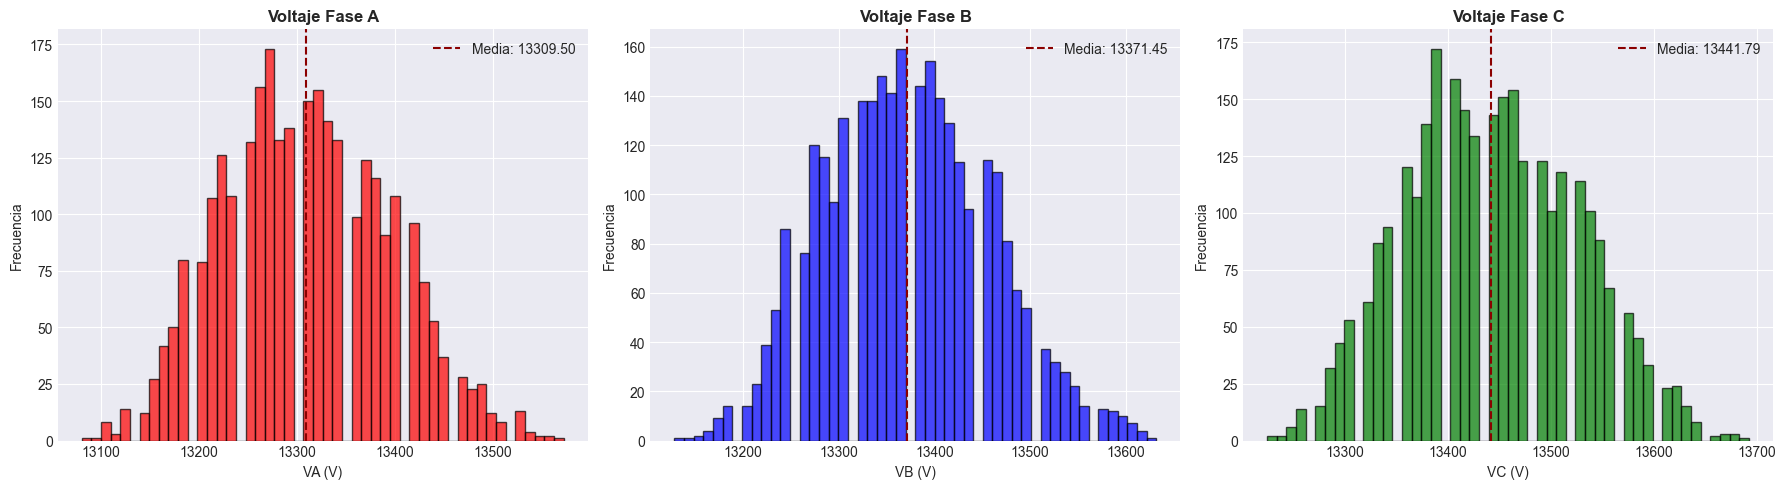

Estadísticas de voltajes por fase:
            VA       VB       VC
count  2881.00  2881.00  2881.00
mean  13309.50 13371.45 13441.79
std      84.25    86.19    83.32
min   13080.10 13128.10 13224.10
25%   13248.10 13308.10 13380.10
50%   13308.10 13368.10 13440.10
75%   13368.10 13428.10 13500.10
max   13572.10 13632.10 13692.10


In [9]:
# Distribución de voltajes por fase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fase, color) in enumerate(zip(['VA', 'VB', 'VC'], ['red', 'blue', 'green'])):
    axes[idx].hist(df_clean[fase], bins=50, color=color, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Voltaje Fase {fase[-1]}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'{fase} (V)')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].axvline(df_clean[fase].mean(), color='darkred', linestyle='--', 
                     label=f'Media: {df_clean[fase].mean():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("Estadísticas de voltajes por fase:")
print(df_clean[['VA', 'VB', 'VC']].describe())

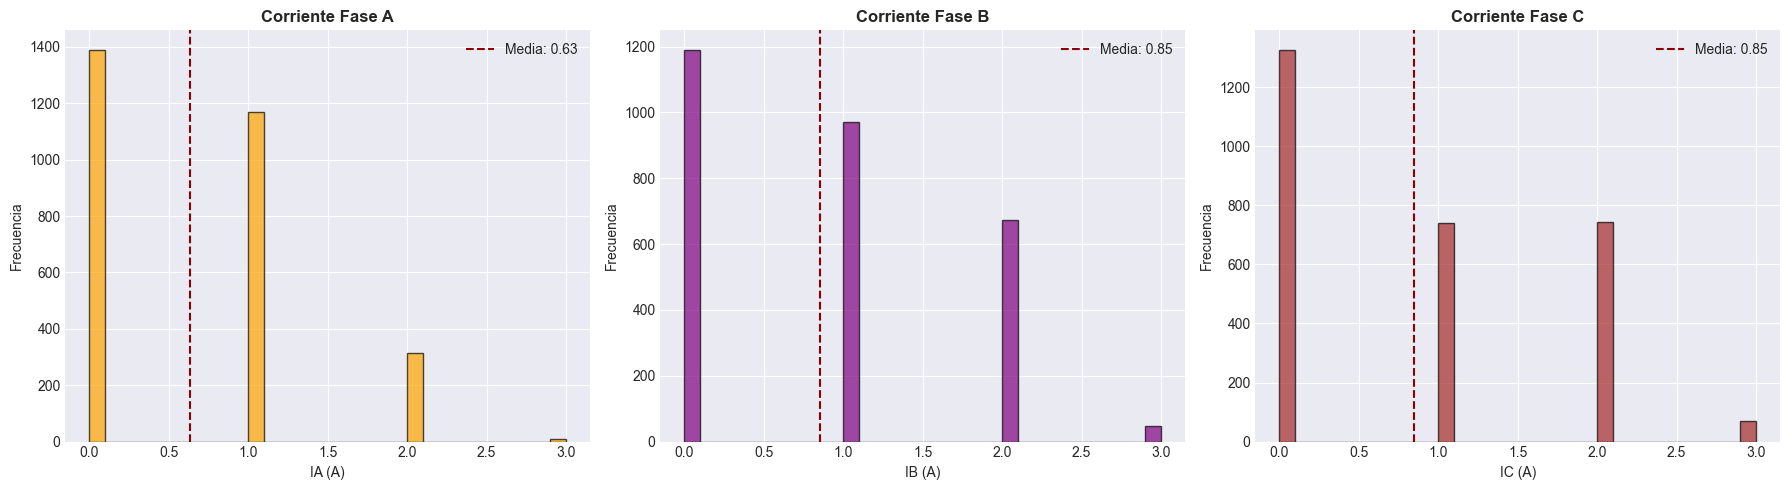

Estadísticas de corrientes por fase:
           IA      IB      IC
count 2881.00 2881.00 2881.00
mean     0.63    0.85    0.85
std      0.69    0.83    0.89
min      0.00    0.00    0.00
25%      0.00    0.00    0.00
50%      1.00    1.00    1.00
75%      1.00    2.00    2.00
max      3.00    3.00    3.00


In [10]:
# Distribución de corrientes por fase
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (fase, color) in enumerate(zip(['IA', 'IB', 'IC'], ['orange', 'purple', 'brown'])):
    axes[idx].hist(df_clean[fase], bins=30, color=color, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Corriente Fase {fase[-1]}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(f'{fase} (A)')
    axes[idx].set_ylabel('Frecuencia')
    axes[idx].axvline(df_clean[fase].mean(), color='darkred', linestyle='--', 
                     label=f'Media: {df_clean[fase].mean():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("Estadísticas de corrientes por fase:")
print(df_clean[['IA', 'IB', 'IC']].describe())

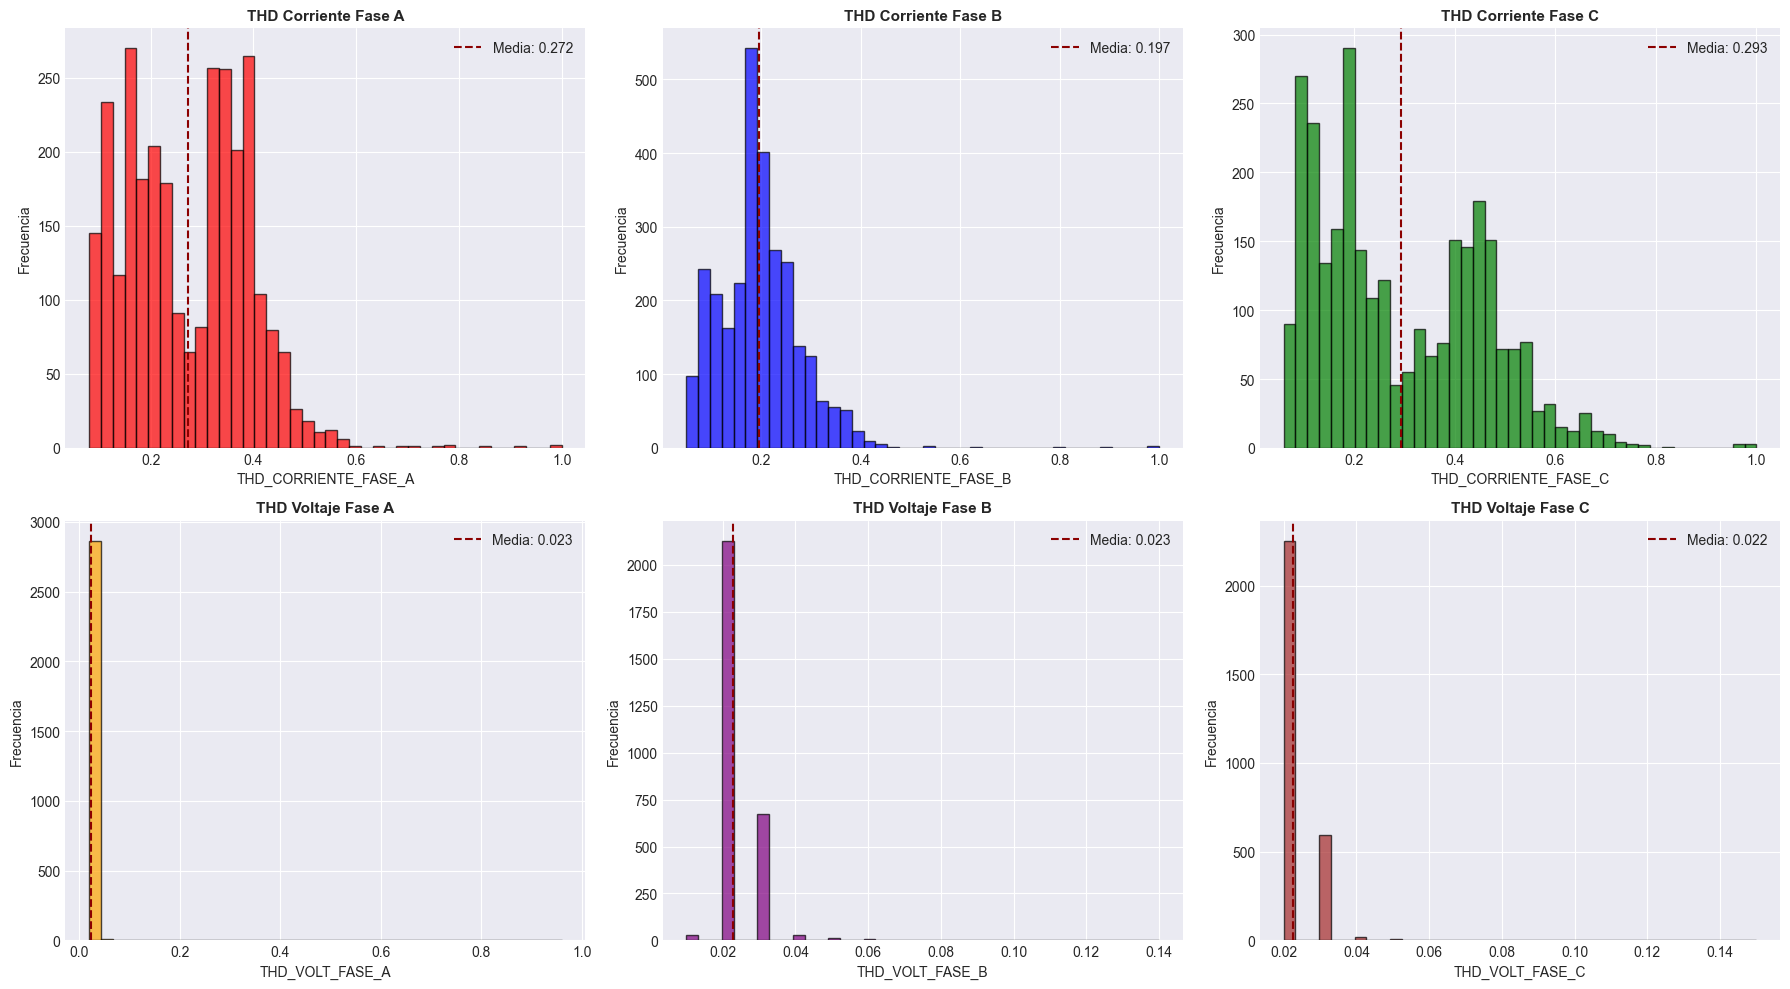

Estadísticas de THD:
       THD_CORRIENTE_FASE_A  THD_CORRIENTE_FASE_B  THD_CORRIENTE_FASE_C  \
count               2881.00               2881.00               2881.00   
mean                   0.27                  0.20                  0.29   
std                    0.12                  0.08                  0.16   
min                    0.08                  0.05                  0.06   
25%                    0.17                  0.15                  0.15   
50%                    0.27                  0.19                  0.25   
75%                    0.36                  0.24                  0.43   
max                    1.00                  1.00                  1.00   

       THD_VOLT_FASE_A  THD_VOLT_FASE_B  THD_VOLT_FASE_C  
count          2881.00          2881.00          2881.00  
mean              0.02             0.02             0.02  
std               0.02             0.01             0.01  
min               0.02             0.01             0.02  
25%     

In [11]:
# Distribución de THD (Total Harmonic Distortion)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# THD de corriente
for idx, (fase, color) in enumerate(zip(['THD_CORRIENTE_FASE_A', 'THD_CORRIENTE_FASE_B', 'THD_CORRIENTE_FASE_C'], 
                                        ['red', 'blue', 'green'])):
    axes[0, idx].hist(df_clean[fase], bins=40, color=color, edgecolor='black', alpha=0.7)
    axes[0, idx].set_title(f'THD Corriente Fase {fase[-1]}', fontsize=11, fontweight='bold')
    axes[0, idx].set_xlabel(f'{fase}')
    axes[0, idx].set_ylabel('Frecuencia')
    axes[0, idx].axvline(df_clean[fase].mean(), color='darkred', linestyle='--',
                        label=f'Media: {df_clean[fase].mean():.3f}')
    axes[0, idx].legend()

# THD de voltaje
for idx, (fase, color) in enumerate(zip(['THD_VOLT_FASE_A', 'THD_VOLT_FASE_B', 'THD_VOLT_FASE_C'], 
                                        ['orange', 'purple', 'brown'])):
    axes[1, idx].hist(df_clean[fase], bins=40, color=color, edgecolor='black', alpha=0.7)
    axes[1, idx].set_title(f'THD Voltaje Fase {fase[-1]}', fontsize=11, fontweight='bold')
    axes[1, idx].set_xlabel(f'{fase}')
    axes[1, idx].set_ylabel('Frecuencia')
    axes[1, idx].axvline(df_clean[fase].mean(), color='darkred', linestyle='--',
                        label=f'Media: {df_clean[fase].mean():.3f}')
    axes[1, idx].legend()

plt.tight_layout()
plt.show()

print("Estadísticas de THD:")
thd_cols = ['THD_CORRIENTE_FASE_A', 'THD_CORRIENTE_FASE_B', 'THD_CORRIENTE_FASE_C',
            'THD_VOLT_FASE_A', 'THD_VOLT_FASE_B', 'THD_VOLT_FASE_C']
print(df_clean[thd_cols].describe())

## 5. Análisis Exploratorio Bivariado

Analizamos las relaciones entre variables mediante correlaciones y visualizaciones bivariadas.

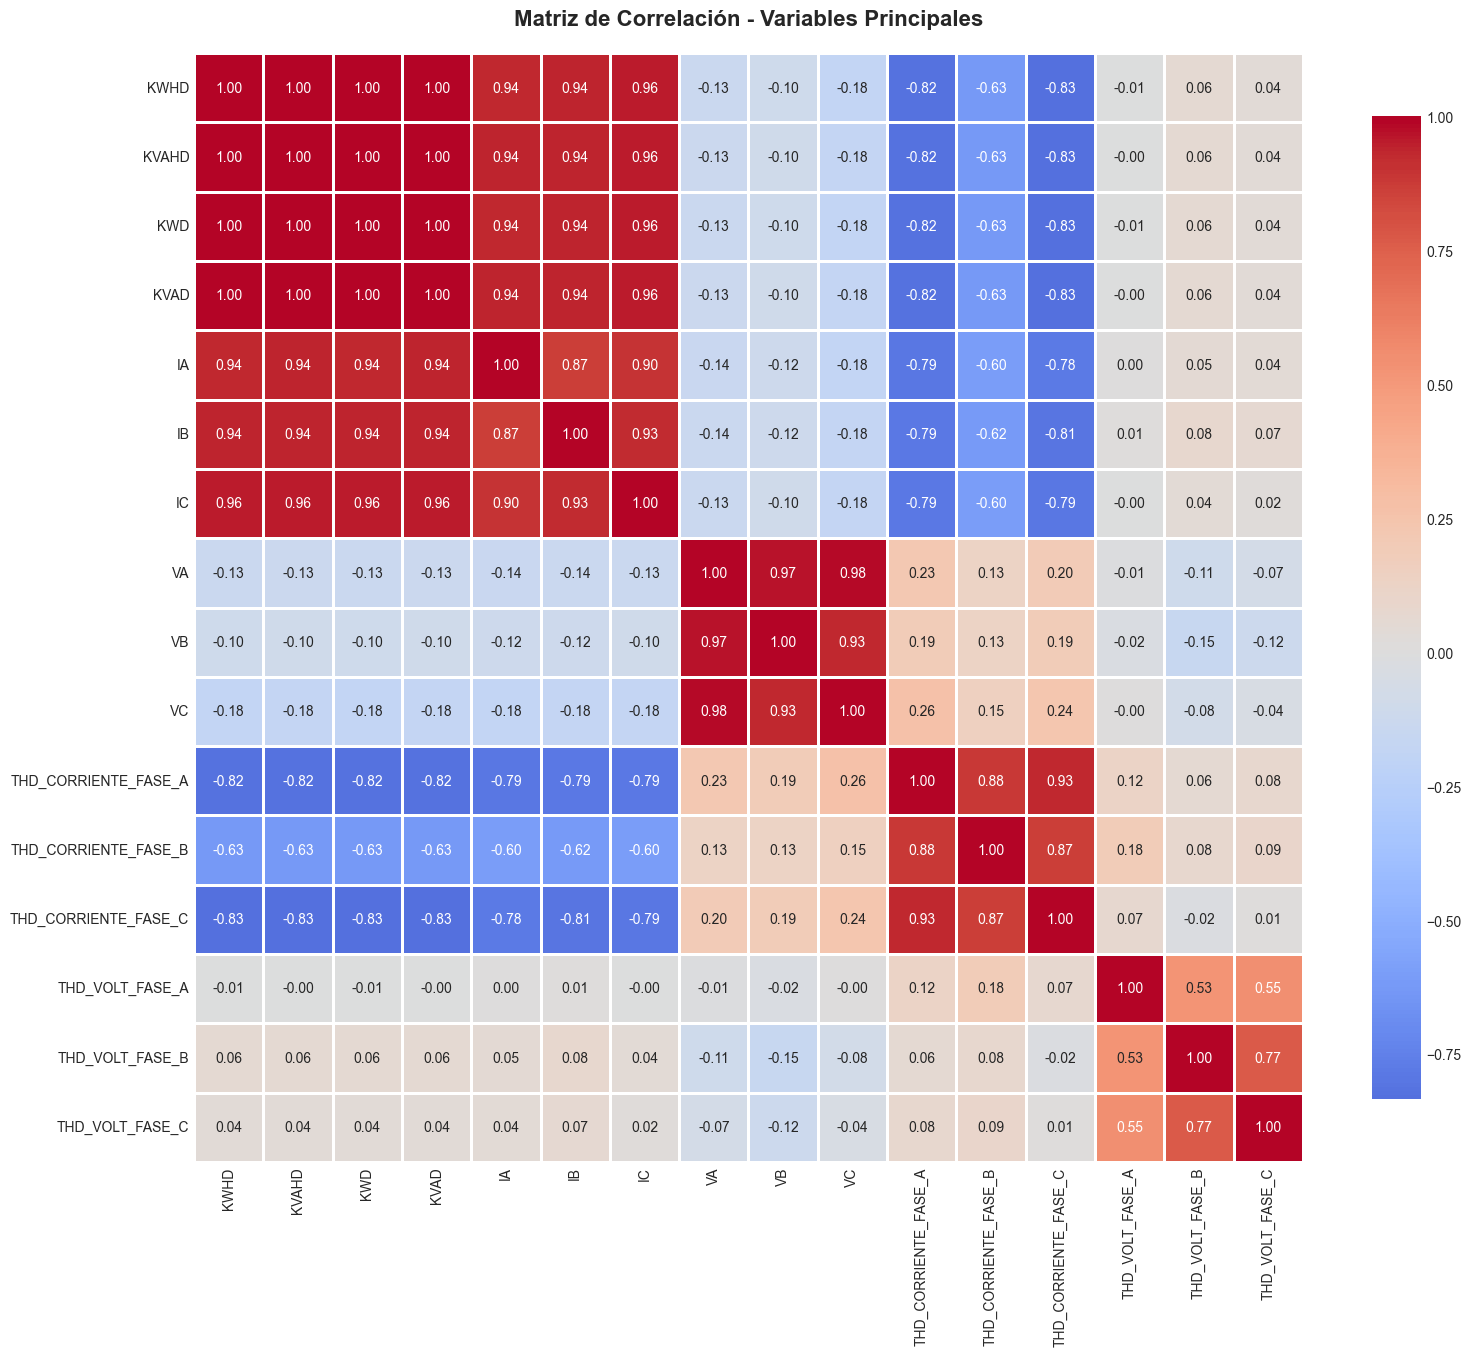


✓ Correlaciones altas (|r| > 0.8):
  KWHD ↔ KWD: 1.000
  KVAHD ↔ KVAD: 1.000
  KWHD ↔ KVAHD: 0.999
  KWHD ↔ KVAD: 0.999
  KVAHD ↔ KWD: 0.999
  KWD ↔ KVAD: 0.999
  VA ↔ VC: 0.985
  VA ↔ VB: 0.967
  KWHD ↔ IC: 0.955
  KWD ↔ IC: 0.955
  KVAHD ↔ IC: 0.955
  KVAD ↔ IC: 0.955
  KVAHD ↔ IB: 0.938
  KVAD ↔ IB: 0.938
  KVAHD ↔ IA: 0.938
  KVAD ↔ IA: 0.938
  KWHD ↔ IB: 0.937
  KWD ↔ IB: 0.937
  KWHD ↔ IA: 0.935
  KWD ↔ IA: 0.935
  VB ↔ VC: 0.932
  THD_CORRIENTE_FASE_A ↔ THD_CORRIENTE_FASE_C: 0.929
  IB ↔ IC: 0.928
  IA ↔ IC: 0.896
  THD_CORRIENTE_FASE_A ↔ THD_CORRIENTE_FASE_B: 0.880
  THD_CORRIENTE_FASE_B ↔ THD_CORRIENTE_FASE_C: 0.869
  IA ↔ IB: 0.868
  KWHD ↔ THD_CORRIENTE_FASE_C: -0.833
  KWD ↔ THD_CORRIENTE_FASE_C: -0.833
  KVAHD ↔ THD_CORRIENTE_FASE_C: -0.832
  KVAD ↔ THD_CORRIENTE_FASE_C: -0.832
  KVAHD ↔ THD_CORRIENTE_FASE_A: -0.821
  KVAD ↔ THD_CORRIENTE_FASE_A: -0.821
  KWHD ↔ THD_CORRIENTE_FASE_A: -0.820
  KWD ↔ THD_CORRIENTE_FASE_A: -0.820
  IB ↔ THD_CORRIENTE_FASE_C: -0.806


In [ ]:
# Matriz de correlación de variables principales
key_vars = ['KWHD', 'KVAHD', 'KWD', 'KVAD', 'IA', 'IB', 'IC', 'VA', 'VB', 'VC',
            'THD_CORRIENTE_FASE_A', 'THD_CORRIENTE_FASE_B', 'THD_CORRIENTE_FASE_C',
            'THD_VOLT_FASE_A', 'THD_VOLT_FASE_B', 'THD_VOLT_FASE_C']

correlation_matrix = df_clean[key_vars].corr()

plt.figure(figsize=(16, 14))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación - Variables Principales', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Identificar correlaciones altas
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            high_corr.append((correlation_matrix.columns[i], 
                            correlation_matrix.columns[j], 
                            correlation_matrix.iloc[i, j]))

print("\nCorrelaciones altas (|r| > 0.8):")
for var1, var2, corr in sorted(high_corr, key=lambda x: abs(x[2]), reverse=True):
    print(f"  {var1} ↔ {var2}: {corr:.3f}")

## 6. Análisis Temporal

Exploramos patrones temporales en el consumo y calidad de potencia.

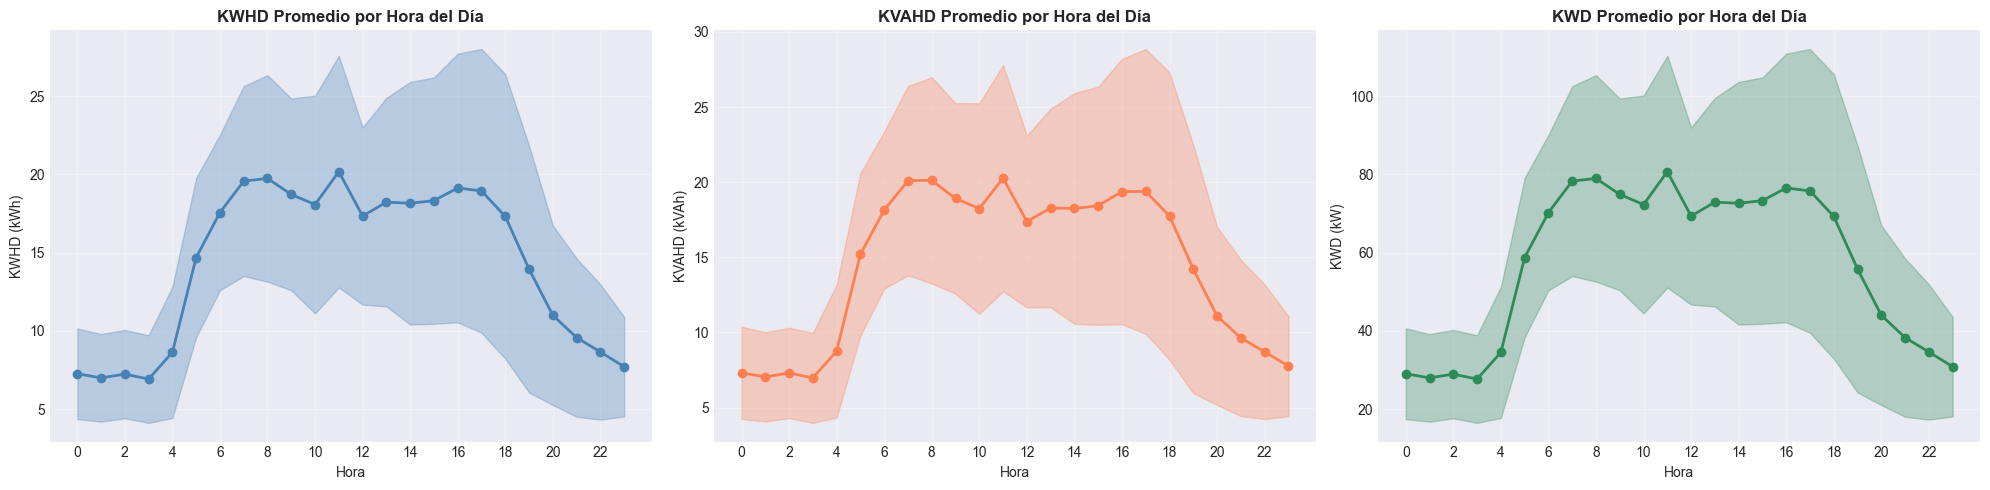

✓ Patrón temporal identificado
  Hora de mayor consumo (KWHD): 11:00
  Hora de menor consumo (KWHD): 3:00


In [ ]:
# Consumo promedio por hora del día
consumo_por_hora = df_clean.groupby('HORA').agg({
    'KWHD': ['mean', 'std'],
    'KVAHD': ['mean', 'std'],
    'KWD': ['mean', 'std']
}).reset_index()

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# KWHD por hora
axes[0].plot(consumo_por_hora['HORA'], consumo_por_hora['KWHD']['mean'], 
            marker='o', linewidth=2, color='steelblue', markersize=6)
axes[0].fill_between(consumo_por_hora['HORA'], 
                     consumo_por_hora['KWHD']['mean'] - consumo_por_hora['KWHD']['std'],
                     consumo_por_hora['KWHD']['mean'] + consumo_por_hora['KWHD']['std'],
                     alpha=0.3, color='steelblue')
axes[0].set_title('KWHD Promedio por Hora del Día', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Hora')
axes[0].set_ylabel('KWHD (kWh)')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 2))

# KVAHD por hora
axes[1].plot(consumo_por_hora['HORA'], consumo_por_hora['KVAHD']['mean'], 
            marker='o', linewidth=2, color='coral', markersize=6)
axes[1].fill_between(consumo_por_hora['HORA'], 
                     consumo_por_hora['KVAHD']['mean'] - consumo_por_hora['KVAHD']['std'],
                     consumo_por_hora['KVAHD']['mean'] + consumo_por_hora['KVAHD']['std'],
                     alpha=0.3, color='coral')
axes[1].set_title('KVAHD Promedio por Hora del Día', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Hora')
axes[1].set_ylabel('KVAHD (kVAh)')
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(range(0, 24, 2))

# KWD por hora
axes[2].plot(consumo_por_hora['HORA'], consumo_por_hora['KWD']['mean'], 
            marker='o', linewidth=2, color='seagreen', markersize=6)
axes[2].fill_between(consumo_por_hora['HORA'], 
                     consumo_por_hora['KWD']['mean'] - consumo_por_hora['KWD']['std'],
                     consumo_por_hora['KWD']['mean'] + consumo_por_hora['KWD']['std'],
                     alpha=0.3, color='seagreen')
axes[2].set_title('KWD Promedio por Hora del Día', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Hora')
axes[2].set_ylabel('KWD (kW)')
axes[2].grid(True, alpha=0.3)
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.show()

print("Patrón temporal identificado")
hora_max = consumo_por_hora.loc[consumo_por_hora['KWHD']['mean'].idxmax(), 'HORA']
hora_min = consumo_por_hora.loc[consumo_por_hora['KWHD']['mean'].idxmin(), 'HORA']
print(f"  Hora de mayor consumo (KWHD): {int(hora_max)}:00")
print(f"  Hora de menor consumo (KWHD): {int(hora_min)}:00")

## 7. Feature Engineering

Creamos variables derivadas que aportan información adicional para el análisis.

In [ ]:
# Crear features temporales
print("Creando features temporales...")
df_featured = engineer_temporal_features(df_clean)
print(f"Features temporales creadas: HORA_SIN, HORA_COS, DIA_SEMANA, ES_FIN_SEMANA, FRANJA, ES_HORA_PICO")

# Crear features eléctricas
print("\nCreando features eléctricas...")
df_featured = engineer_electrical_features(df_featured)
print(f"Features eléctricas creadas: FACTOR_POTENCIA, DESBALANCE_CORRIENTE, DESBALANCE_VOLTAJE")
print(f"                               THD_CORRIENTE_PROMEDIO, THD_VOLTAJE_PROMEDIO, KVAR_APARENTE")

print(f"\nDimensiones después de feature engineering: {df_featured.shape[0]:,} filas × {df_featured.shape[1]} columnas")
print(f"Nuevas features creadas: {df_featured.shape[1] - df_clean.shape[1]}")

Creando features temporales...
✓ Features temporales creadas: HORA_SIN, HORA_COS, DIA_SEMANA, ES_FIN_SEMANA, FRANJA, ES_HORA_PICO

Creando features eléctricas...
✓ Features eléctricas creadas: FACTOR_POTENCIA, DESBALANCE_CORRIENTE, DESBALANCE_VOLTAJE
                               THD_CORRIENTE_PROMEDIO, THD_VOLTAJE_PROMEDIO, KVAR_APARENTE

Dimensiones después de feature engineering: 2,881 filas × 55 columnas
Nuevas features creadas: 16


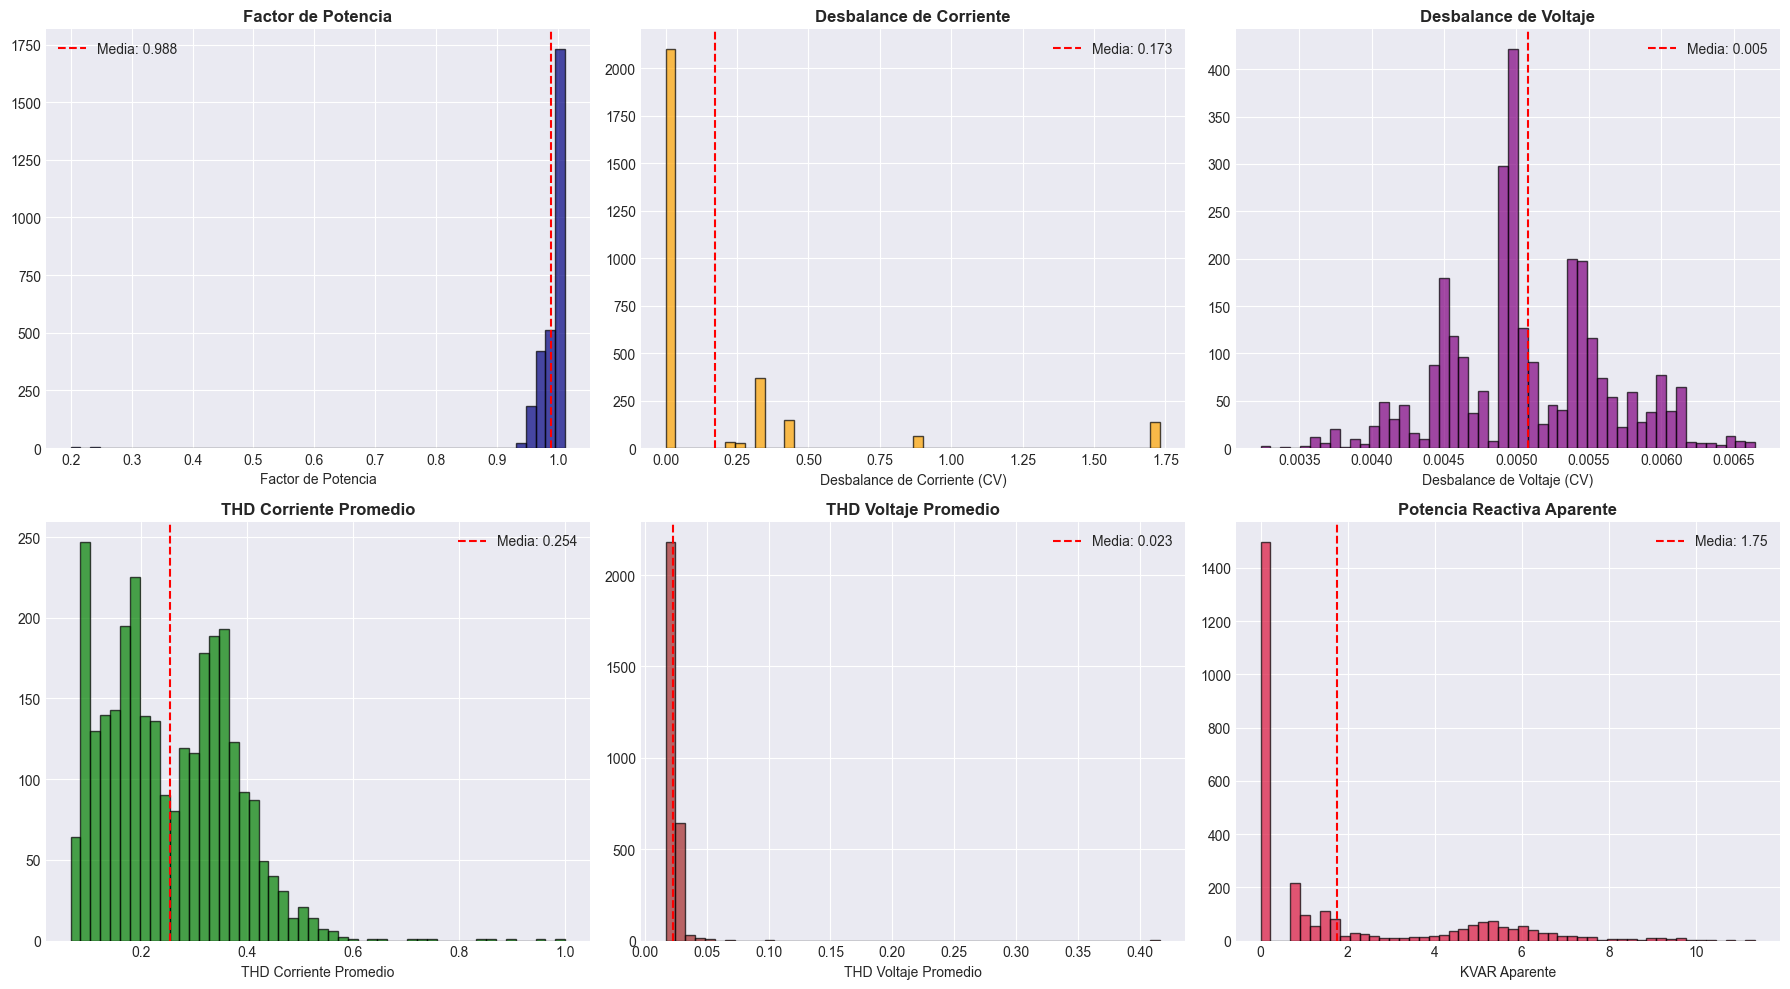

Estadísticas de nuevas features:
       FACTOR_POTENCIA  DESBALANCE_CORRIENTE  DESBALANCE_VOLTAJE  \
count          2881.00               2881.00             2881.00   
mean              0.99                  0.17                0.01   
std               0.05                  0.39                0.00   
min               0.20                  0.00                0.00   
25%               0.98                  0.00                0.00   
50%               1.00                  0.00                0.00   
75%               1.00                  0.25                0.01   
max               1.01                  1.73                0.01   

       THD_CORRIENTE_PROMEDIO  THD_VOLTAJE_PROMEDIO  KVAR_APARENTE  
count                 2881.00               2881.00        2881.00  
mean                     0.25                  0.02           1.75  
std                      0.12                  0.01           2.49  
min                      0.07                  0.02           0.00  
25%      

In [16]:
# Visualizar nuevas features
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Factor de potencia
axes[0, 0].hist(df_featured['FACTOR_POTENCIA'], bins=50, color='navy', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Factor de Potencia', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Factor de Potencia')
axes[0, 0].axvline(df_featured['FACTOR_POTENCIA'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["FACTOR_POTENCIA"].mean():.3f}')
axes[0, 0].legend()

# Desbalance de corriente
axes[0, 1].hist(df_featured['DESBALANCE_CORRIENTE'], bins=50, color='orange', edgecolor='black', alpha=0.7)
axes[0, 1].set_title('Desbalance de Corriente', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Desbalance de Corriente (CV)')
axes[0, 1].axvline(df_featured['DESBALANCE_CORRIENTE'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["DESBALANCE_CORRIENTE"].mean():.3f}')
axes[0, 1].legend()

# Desbalance de voltaje
axes[0, 2].hist(df_featured['DESBALANCE_VOLTAJE'], bins=50, color='purple', edgecolor='black', alpha=0.7)
axes[0, 2].set_title('Desbalance de Voltaje', fontsize=12, fontweight='bold')
axes[0, 2].set_xlabel('Desbalance de Voltaje (CV)')
axes[0, 2].axvline(df_featured['DESBALANCE_VOLTAJE'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["DESBALANCE_VOLTAJE"].mean():.3f}')
axes[0, 2].legend()

# THD Corriente Promedio
axes[1, 0].hist(df_featured['THD_CORRIENTE_PROMEDIO'], bins=50, color='green', edgecolor='black', alpha=0.7)
axes[1, 0].set_title('THD Corriente Promedio', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('THD Corriente Promedio')
axes[1, 0].axvline(df_featured['THD_CORRIENTE_PROMEDIO'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["THD_CORRIENTE_PROMEDIO"].mean():.3f}')
axes[1, 0].legend()

# THD Voltaje Promedio
axes[1, 1].hist(df_featured['THD_VOLTAJE_PROMEDIO'], bins=50, color='brown', edgecolor='black', alpha=0.7)
axes[1, 1].set_title('THD Voltaje Promedio', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('THD Voltaje Promedio')
axes[1, 1].axvline(df_featured['THD_VOLTAJE_PROMEDIO'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["THD_VOLTAJE_PROMEDIO"].mean():.3f}')
axes[1, 1].legend()

# KVAR Aparente
axes[1, 2].hist(df_featured['KVAR_APARENTE'], bins=50, color='crimson', edgecolor='black', alpha=0.7)
axes[1, 2].set_title('Potencia Reactiva Aparente', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('KVAR Aparente')
axes[1, 2].axvline(df_featured['KVAR_APARENTE'].mean(), color='red', linestyle='--',
                  label=f'Media: {df_featured["KVAR_APARENTE"].mean():.2f}')
axes[1, 2].legend()

plt.tight_layout()
plt.show()

print("Estadísticas de nuevas features:")
new_features = ['FACTOR_POTENCIA', 'DESBALANCE_CORRIENTE', 'DESBALANCE_VOLTAJE',
                'THD_CORRIENTE_PROMEDIO', 'THD_VOLTAJE_PROMEDIO', 'KVAR_APARENTE']
print(df_featured[new_features].describe())

## 8. Detección de Outliers

Identificamos valores atípicos que podrían afectar el análisis.

Conteo de outliers por variable:
DESBALANCE_CORRIENTE    201
FACTOR_POTENCIA         182
DESBALANCE_VOLTAJE        8
dtype: int64


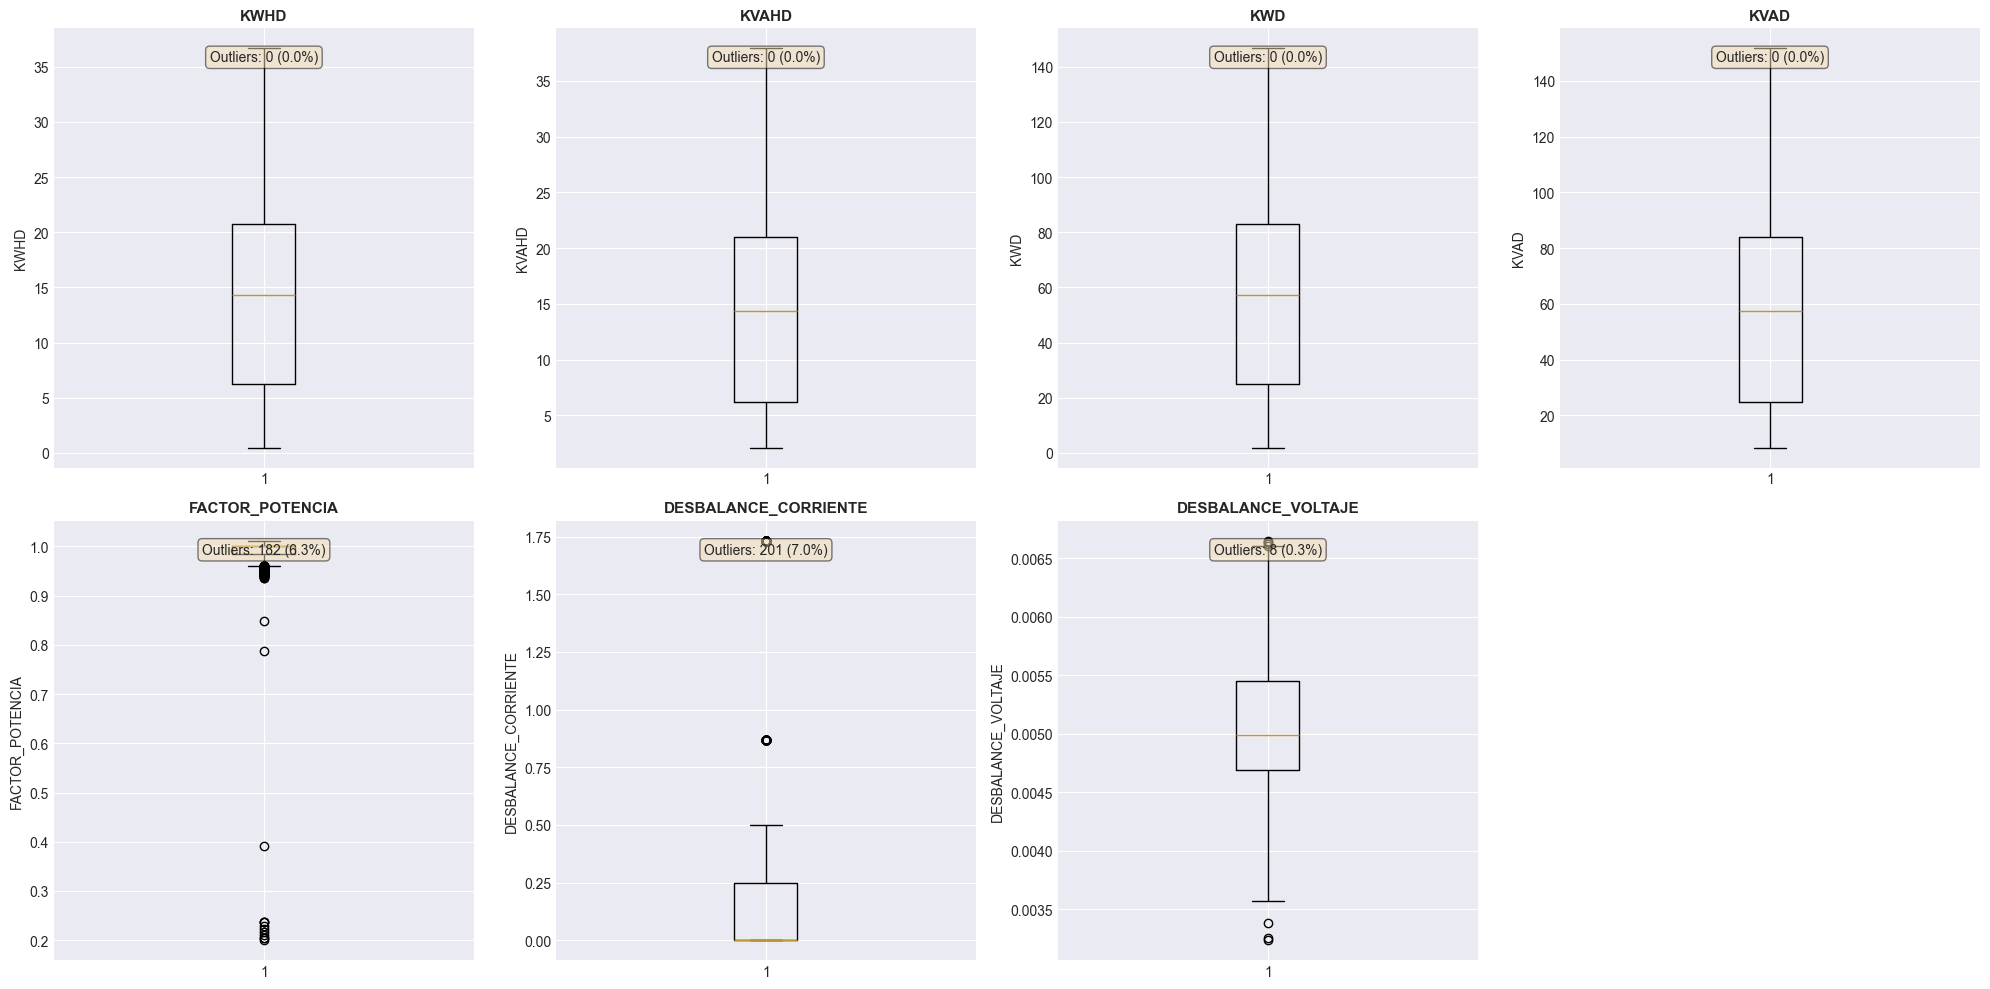


✓ Total de registros con al menos un outlier: 389 (13.5%)
✓ Los outliers se mantendrán en el dataset (pueden representar eventos operativos reales)


In [ ]:
# Detectar outliers usando IQR
outlier_vars = ['KWHD', 'KVAHD', 'KWD', 'KVAD', 'FACTOR_POTENCIA', 
                'DESBALANCE_CORRIENTE', 'DESBALANCE_VOLTAJE']

outliers = detect_outliers_iqr(df_featured, columns=outlier_vars, threshold=1.5)

outlier_counts = outliers.sum().sort_values(ascending=False)

print("Conteo de outliers por variable:")
print(outlier_counts[outlier_counts > 0])

# Visualizar outliers con boxplots
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.ravel()

for idx, var in enumerate(outlier_vars):
    axes[idx].boxplot(df_featured[var], vert=True)
    axes[idx].set_title(f'{var}', fontsize=11, fontweight='bold')
    axes[idx].set_ylabel(var)
    n_outliers = outliers[var].sum()
    axes[idx].text(0.5, 0.95, f'Outliers: {n_outliers} ({100*n_outliers/len(df_featured):.1f}%)',
                  transform=axes[idx].transAxes, ha='center', va='top',
                  bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Ocultar el último subplot si no se usa
if len(outlier_vars) < 8:
    axes[7].axis('off')

plt.tight_layout()
plt.show()

# Resumen de outliers
total_outliers_any_var = outliers.any(axis=1).sum()
print(f"\nTotal de registros con al menos un outlier: {total_outliers_any_var} ({100*total_outliers_any_var/len(df_featured):.1f}%)")
print(f"Los outliers se mantendrán en el dataset (pueden representar eventos operativos reales)")

## 9. Normalización y Preparación Final

Preparamos los datos para los algoritmos de machine learning mediante normalización.

In [18]:
# Preparar features para ML (normalización)
exclude_cols = ['FECHA', 'INTERVALO', 'CATEGORIA', 'DENSIDADCARGA', 'TIPO_INSTALACION', 'FRANJA']

X_scaled, scaler = prepare_features_for_ml(df_featured, exclude_cols=exclude_cols, scale=True)

print(f"✓ Features normalizadas exitosamente")
print(f"✓ Dimensiones de matriz de features: {X_scaled.shape[0]:,} filas × {X_scaled.shape[1]} columnas")
print(f"\nColumnas excluidas de la normalización:")
for col in exclude_cols:
    if col in df_featured.columns:
        print(f"  - {col}")

# Verificar normalización
print(f"\n✓ Verificación de normalización (primeras 5 features):")
print(f"  Media: {X_scaled.iloc[:, :5].mean().mean():.6f} (esperado: ~0)")
print(f"  Std: {X_scaled.iloc[:, :5].std().mean():.6f} (esperado: ~1)")

✓ Features normalizadas exitosamente
✓ Dimensiones de matriz de features: 2,881 filas × 47 columnas

Columnas excluidas de la normalización:
  - FECHA
  - INTERVALO
  - CATEGORIA
  - DENSIDADCARGA
  - TIPO_INSTALACION
  - FRANJA

✓ Verificación de normalización (primeras 5 features):
  Media: 0.000000 (esperado: ~0)
  Std: 1.000174 (esperado: ~1)


## 10. Resumen y Exportación

Resumen del preprocesamiento y exportación de datos limpios.

In [19]:
# Exportar datos procesados
output_path_featured = Path.cwd().parent / 'data' / 'processed_data_featured.csv'
output_path_scaled = Path.cwd().parent / 'data' / 'processed_data_scaled.csv'

# Guardar datos con features engineering
df_featured.to_csv(output_path_featured, index=False)
print(f"✓ Datos con features guardados en: {output_path_featured}")

# Combinar datos escalados con columnas no numéricas para contexto
df_scaled_full = X_scaled.copy()
for col in ['FECHA', 'HORA', 'INTERVALO', 'CATEGORIA']:
    if col in df_featured.columns:
        df_scaled_full[col] = df_featured[col].values

df_scaled_full.to_csv(output_path_scaled, index=False)
print(f"✓ Datos normalizados guardados en: {output_path_scaled}")

# Guardar scaler para uso posterior
import pickle
scaler_path = Path.cwd().parent / 'data' / 'scaler.pkl'
with open(scaler_path, 'wb') as f:
    pickle.dump(scaler, f)
print(f"✓ Scaler guardado en: {scaler_path}")

✓ Datos con features guardados en: d:\Desktop\Proyecto no supervizado\data\processed_data_featured.csv
✓ Datos normalizados guardados en: d:\Desktop\Proyecto no supervizado\data\processed_data_scaled.csv
✓ Scaler guardado en: d:\Desktop\Proyecto no supervizado\data\scaler.pkl


In [20]:
# Resumen final del preprocesamiento
print("="*80)
print("RESUMEN DEL PREPROCESAMIENTO")
print("="*80)

print(f"\nDATASET ORIGINAL:")
print(f"  - Registros: {df_raw.shape[0]:,}")
print(f"  - Variables: {df_raw.shape[1]}")
print(f"  - Periodo: {df_raw['FECHA'].min().date()} a {df_raw['FECHA'].max().date()}")

print(f"\nLIMPIEZA:")
print(f"  - Columnas eliminadas (varianza cero): {len(removed_cols)}")
print(f"  - Valores faltantes: 0")
print(f"  - Variables después de limpieza: {df_clean.shape[1]}")

print(f"\nFEATURE ENGINEERING:")
print(f"  - Features temporales creadas: 6")
print(f"    (HORA_SIN, HORA_COS, DIA_SEMANA, ES_FIN_SEMANA, FRANJA, ES_HORA_PICO)")
print(f"  - Features eléctricas creadas: 9")
print(f"    (FACTOR_POTENCIA, DESBALANCE_CORRIENTE, DESBALANCE_VOLTAJE,")
print(f"     CORRIENTE_MEDIA, CORRIENTE_STD, VOLTAJE_MEDIO, VOLTAJE_STD,")
print(f"     THD_CORRIENTE_PROMEDIO, THD_VOLTAJE_PROMEDIO, KVAR_APARENTE)")
print(f"  - Total de variables con features: {df_featured.shape[1]}")

print(f"\nOUTLIERS:")
print(f"  - Registros con outliers: {total_outliers_any_var} ({100*total_outliers_any_var/len(df_featured):.1f}%)")
print(f"  - Decisión: Mantener (pueden ser eventos operativos reales)")

print(f"\nNORMALIZACIÓN:")
print(f"  - Método: StandardScaler (media=0, std=1)")
print(f"  - Features normalizadas: {X_scaled.shape[1]}")
print(f"  - Columnas excluidas: {len(exclude_cols)}")

print(f"\nARCHIVOS EXPORTADOS:")
print(f"  - processed_data_featured.csv ({df_featured.shape[0]:,} × {df_featured.shape[1]})")
print(f"  - processed_data_scaled.csv ({df_scaled_full.shape[0]:,} × {df_scaled_full.shape[1]})")
print(f"  - scaler.pkl (objeto StandardScaler)")

print(f"\nDATOS LISTOS PARA:")
print(f"  - Reducción de dimensionalidad (PCA, UMAP)")
print(f"  - Clustering (K-means, DBSCAN)")
print(f"  - Análisis de perfiles operativos")

print("\n" + "="*80)
print("PREPROCESAMIENTO COMPLETADO")
print("="*80)

RESUMEN DEL PREPROCESAMIENTO

📊 DATASET ORIGINAL:
  • Registros: 2,881
  • Variables: 47
  • Periodo: 2025-10-01 a 2025-10-31

🧹 LIMPIEZA:
  • Columnas eliminadas (varianza cero): 8
  • Valores faltantes: 0
  • Variables después de limpieza: 39

⚙️ FEATURE ENGINEERING:
  • Features temporales creadas: 6
    - HORA_SIN, HORA_COS, DIA_SEMANA, ES_FIN_SEMANA, FRANJA, ES_HORA_PICO
  • Features eléctricas creadas: 9
    - FACTOR_POTENCIA, DESBALANCE_CORRIENTE, DESBALANCE_VOLTAJE
    - CORRIENTE_MEDIA, CORRIENTE_STD, VOLTAJE_MEDIO, VOLTAJE_STD
    - THD_CORRIENTE_PROMEDIO, THD_VOLTAJE_PROMEDIO, KVAR_APARENTE
  • Total de variables con features: 55

📉 OUTLIERS:
  • Registros con outliers: 389 (13.5%)
  • Decisión: Mantener (pueden ser eventos operativos reales)

🔄 NORMALIZACIÓN:
  • Método: StandardScaler (media=0, std=1)
  • Features normalizadas: 47
  • Columnas excluidas: 6

💾 ARCHIVOS EXPORTADOS:
  • processed_data_featured.csv (2,881 × 55)
  • processed_data_scaled.csv (2,881 × 50)
  • sc